compared to

https://saemiller.com/flow/SAEMiller_Comp_Calc.html

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits import mplot3d
%matplotlib inline

<h1>GENERATING FIRST WAVERIDER</h1>
higher speed body

In [2]:
#flow field charcteristics for waverider 1

B = 6.9 * np.pi/180 #shock angle
M1 = 13 #freestream mach number
#check for B validity
mu = np.arcsin(1/M1)
if B<=mu:
    print('WARNING: Shock Angle less than or equal to Mach Angle')

#stagnation atmospheric conditions taken from ISA
p01 = 101325 #Pa from ISA table at 0 elevation
rho01 = 1.225 #kg/m3
T01 = 288.15 #K
#static atmospheric values calculated using isentropic compressible flow relations
Tupper = T01 * (1+M1**2*(1.4-1)/2)**-1
rhoupper = rho01 * (1+M1**2*(1.4-1)/2)**(-1/(1.4-1))
pupper = p01*(1+(1.4-1)/2*M1**2)**(-1.4/(1.4-1))

d = np.arctan((2*(M1**2*np.sin(B)**2-1))/(np.tan(B)*((1.4+1)*M1**2-2*(M1**2*np.sin(B)**2-1)))) #turning angle
print('turning angle =',d * 180/np.pi,'degrees')
print('static pressure before shock =',pupper,'Pa')
print('static density before shock=',rhoupper,'kg/m3')
print('static temperature before shock=',Tupper,'K')

turning angle = 3.3800052938739893 degrees
static pressure before shock = 0.4075578463123612 Pa
static density before shock= 0.00017146993326716957 kg/m3
static temperature before shock= 8.280172413793105 K


In [3]:
M1n = M1*np.sin(B)
M2n = np.sqrt((1+((1.4-1)/2)*M1n**2)/(1.4*M1n**2-(1.4-1)/2))
M2 = M2n/np.sin(B-d)
print(M2)

11.080328404832116


In [4]:
vi = (2/((1.4-1)*M2**2) +1)**(-0.5) #non dimensionalised version of V right after the shock, depicted as V' in Anderson
vri = vi*np.cos(B-d)
vti = vi*np.sin(B-d)
print(vri, vti)
print(np.tan(vti/vri)*180/np.pi)

0.9783896182648967 0.06018358916672094
3.528881960092447


In [5]:
#Taylor-Maccoll Solution to find cone body surface for waverider 1

vr = vri
vt = -vti
dt = 0.0000001
n = 0
v_rad = []
v_theta = []
theta = []
while vt<0:
    R = (vr*vt**2-((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)*(2.0*vr+vt/np.tan(B-dt*n)))/(((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)-vt**2.0)
    vr = vr-dt*vt
    vt = vt-dt*R
    n=n+1
    v_rad.append(vr)
    v_theta.append(vt)
    theta.append(B-dt*n)
print(n)
#print((B-dt*n)*180/np.pi,',', vt,',',n)
Bans1 = (-v_theta[n-1])*((theta[n-1]-theta[n-2])/v_theta[n-1]-v_theta[n-2])+theta[n-1] #cone angle
print(Bans1*180/np.pi)

333837
4.9872606150466625


In [6]:
#generating waverider body

rc = 1 #cone radius in m
amax = 21       *np.pi/180 #max angle of osculating plane
L=round(rc/np.tan(Bans1), 14) #length of cone
p = 101 #number of osculating planes

#osculating planes
a=np.linspace(-np.pi+amax, -np.pi-amax, p)

#base plane
rs = L*np.tan(B) #radius of shock in back plane

p2 = [] #arc of shock cone in back plane
for i in range(len(a)):
    p2.append((L, rs*np.cos(a[i]), rs*np.sin(a[i])))

p1 = [] #design of upper surface
scale= 1
yint = scale*rs**2*(np.sin(amax))**2-rs*np.cos(amax)
p1lims=[-rs*np.sin(amax), rs*np.sin(amax)]

z=np.linspace(p1lims[0], p1lims[1], p)
for i in range(p):
    # if a[i]<-np.pi/2:
    #     z = (np.tan(a[i])+np.sqrt(np.tan(a[i])**2-4*scale*yint))/(-2*scale)
    # else:
    #     z = (np.tan(a[i])-np.sqrt(np.tan(a[i])**2-4*scale*yint))/(-2*scale)
    p1.append((L, (yint-scale*z[i]**2), z[i]))
    # p1.append((L, (yint-scale*z**2), z))
    

p3 = [] #leading edge found by projecting upper surface onto shock cone
for i in range(len(a)):
    p3.append(((p1[i][0]-(-rs*np.cos(amax)-p1[i][1])/np.tan(-B)), p1[i][1], p1[i][2]))
    
p4 = [] #lower surface points found by straight line approximation onto back plane
for i in range(len(a)):
    p4.append((p1[i][0], p1[i][1]-(p1[i][0]-p3[i][0])*np.tan(Bans1), p1[i][2]))



In [7]:
#separating out points in x,y,z
p1x=[]
for i in range(len(a)):
    p1x.append(p1[i][0])

p1y=[]
for i in range(len(a)):
    p1y.append(p1[i][1])
    
p1z=[]
for i in range(len(a)):
    p1z.append(p1[i][2])
    

    
p2x=[]
for i in range(len(a)):
    p2x.append(p2[i][0])

p2y=[]
for i in range(len(a)):
    p2y.append(p2[i][1])
    
p2z=[]
for i in range(len(a)):
    p2z.append(p2[i][2])
    
    

p3x=[]
for i in range(len(a)):
    p3x.append(p3[i][0])

p3y=[]
for i in range(len(a)):
    p3y.append(p3[i][1])
    
p3z=[]
for i in range(len(a)):
    p3z.append(p3[i][2])
    


p4x=[]
for i in range(len(a)):
    p4x.append(p4[i][0])

p4y=[]
for i in range(len(a)):
    p4y.append(p4[i][1])
    
p4z=[]
for i in range(len(a)):
    p4z.append(p4[i][2])

In [8]:
#straight line surface plotting
sx1 = []
sy1 = []
sz1 = []
vtlower = []
vrlower = []
dx = 0.01
inplane = []
for i in range(p):
    xn = p3x[i]
    yn = p3y[i]
    zn = p3z[i]
    vt = -vti
    vr = vri
    n = 0
    while xn <= L:
        sx1.append(xn)
        sy1.append(yn)
        sz1.append(zn)
        vtlower.append(vt)
        vrlower.append(vr)
        rn = np.sqrt(xn**2+yn**2+zn**2)
        tn = np.arccos(xn/rn)
        R  = (vr*vt**2-((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)*(2.0*vr+vt/np.tan(Bans1)))/(((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)-vt**2.0)
        vr = vr-dt*vt
        vt = vt-dt*R 
        xn = xn + dx
        yn = yn - dx*np.tan(Bans1)
        n  = n + 1
    inplane.append(n)

inplane = np.cumsum(inplane)


#streamline plotting
sx2 = []
sy2 = []
sz2 = []
vtlower = []
vrlower = []
inplane = []
for i in range(p):
    rn = (p3x[i]**2 + p3y[i]**2 + p3z[i]**2)**0.5
    tn = np.arccos(p3x[i]/(p3x[i]**2+p3y[i]**2+p3z[i]**2)**0.5)
    vt = -vti
    vr = vri
    dr = 0.001
    n = 0
    while rn*np.cos(tn)<=L:        
        sx2.append(rn*np.cos(tn))
        sy2.append(rn*np.sin(tn)*np.cos(a[i]))
        sz2.append(rn*np.sin(tn)*np.sin(a[i]))
        vtlower.append(vt)
        vrlower.append(vr)
        R  = (vr*vt**2-((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)*(2.0*vr+vt/np.tan(tn)))/(((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)-vt**2.0)
        dt = (vt*dr)/(rn*vr)
        vr = vr + dt*vt
        vt = vt + dt*R
        tn = tn + dt
        rn = rn + dr
        n = n + 1
    inplane.append(n)
    



#print(i)
#print(len(sx)+len(sy)+len(sz))
#print(np.tan(vtlower[i]/vrlower[i])*180/np.pi,' ',np.tan(vtlower[0]/vrlower[0])*180/np.pi)

i = 5
rn = (1**2 + (-1)**2 + (-1)**2)**0.5
tn = np.arccos(1/rn)
x = rn*np.cos(tn)
y = rn*np.sin(tn)*np.cos(a[i])
z = rn*np.sin(tn)*np.sin(a[i])
print(p3x[i], p3y[i], p3z[i])
print(x,y,z)

In [9]:
#calculating pressure for each point on surface

Mlower = []
plower = []
p02 = p01*(((1.4+1)/2*M1**2)/(1+(1.4-1)/2*M1**2))**(1.4/(1.4-1))*(1/(2*1.4/(1.4+1)*M1**2-(1.4-1)/(1.4+1)))**(1/(1.4-1))
for i in range(len(vtlower)):
    Mlower.append((2/(0.4*((vtlower[i]**2+vrlower[i]**2)**-1 -1)))**0.5)
    plower.append((1.0+(2.0*1.4*(Mlower[i]**2.0-1.0))/(1.4+1.0))*pupper)

#calculating spanwise lift distribution
lift2d = []
dz1 = (p1z[p-1] - p1z[0])/p
dy = (p1y[p-1] - p1y[0])/(np.ceil(p/2))
n = inplane[0] - 1
i = 0
liftline = []
while i <= (p-1):
    lifttemp = []    
    while n <= (inplane[i]-1):
        lifttemp.append(-(plower[n] - pupper)*(L-p3x[i])*np.cos(a[i]))
        n = n + 1
    n = inplane[i]
    liftline.append(lifttemp)
    i = i + 1

for i in range(p):
    lift2d.append(np.trapezoid(liftline[i], x=None , dx=dx))

lift = np.trapezoid(lift2d, x=None, dx=dz1)

cl1 = lift/(0.5*rhoupper*M1**2*1.4*287*Tupper)

#calculating drag number from base drag which gives pressure drag
cpbase = (2/(1.4*M1**2))*((2/(1.4+1))**1.4*(1/M1)**2.8*((2*1.4*M1**2-(1.4-1))/(1.4+1))-1)
pbase = pupper + 0.5*rhoupper*M1**2*1.4*287*Tupper*cpbase
drag2d = []
dragline = []
n = inplane[0] - 1
i = 0
while i <= (p-1):
    dragtemp = []    
    while n <= (inplane[i]-1):
        dragtemp.append((p1y[i]-p4y[i])*(plower[n]-pbase))
        n = n + 1
    n = inplane[i]
    dragline.append(dragtemp)
    i = i + 1

for i in range(p):
    drag2d.append(np.trapezoid(dragline[i], x=None , dx=dx))

drag = np.trapezoid(drag2d, x=None, dx=dz1)
cd1 = drag/(0.5*rhoupper*M1**2*1.4*287*Tupper)
print(cl1)
print(lift/drag)

2.594024471977747
11.279796113302554


<h3>Plotting in each plane</h3>

Text(0, 0.5, 'Lift (N)')

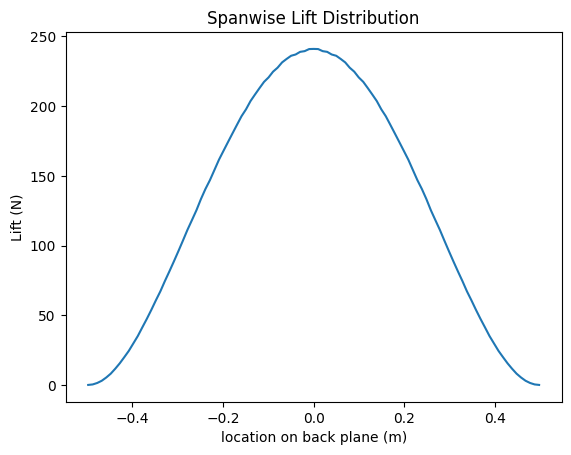

In [10]:
%matplotlib inline
plt.plot(p1z, lift2d)
plt.title('Spanwise Lift Distribution')
plt.xlabel('location on back plane (m)')
plt.ylabel('Lift (N)')

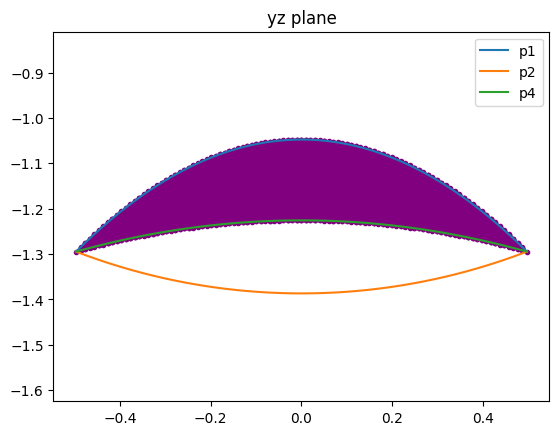

In [11]:
%matplotlib inline
plt.plot(p1z,p1y, label='p1')
plt.plot(p2z,p2y, label='p2')
#plt.plot(p3z,p3y, label='p3')
plt.plot(p4z,p4y, label='p4')
plt.scatter(sz1,sy1, marker='.', color='purple')
plt.title('yz plane')
plt.axis('equal')
plt.legend()

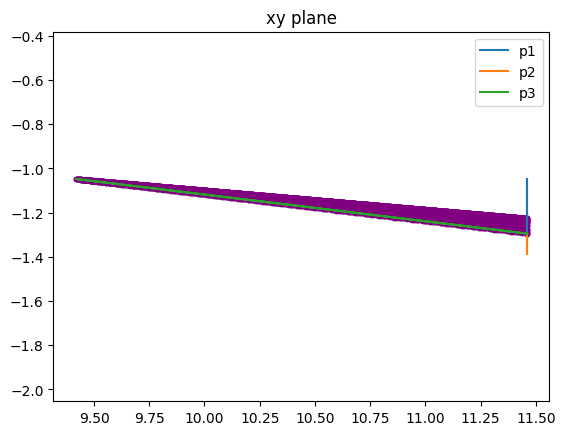

In [12]:
%matplotlib inline
plt.plot(p1x,p1y, label='p1')
plt.plot(p2x,p2y, label='p2')
plt.plot(p3x,p3y, label='p3')
plt.scatter(sx1, sy1, marker=".", color='purple')
#plt.plot(p4x,p4y, label='p4')
# x=np.linspace(0,L,p)
# y=-np.tan(B)*x
# plt.plot(x,y, label='shock')
plt.title('xy plane')
plt.axis('equal')
plt.legend()

(np.float64(9.316485841423413),
 np.float64(11.561441047504596),
 np.float64(-0.5466592847795255),
 np.float64(0.5466592847795255))

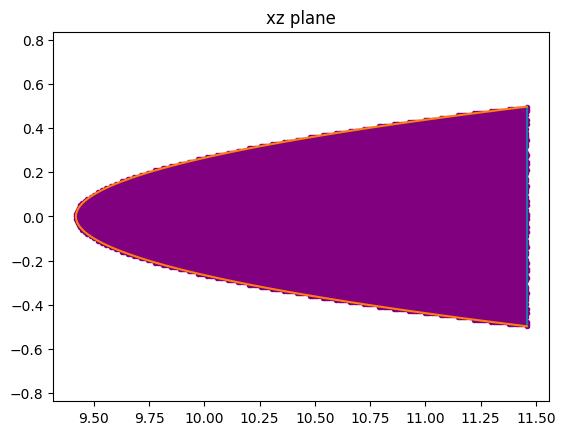

In [13]:
%matplotlib inline
plt.title('xz plane')
plt.plot(p1x,p3z)
plt.plot(p3x,p3z)
plt.scatter(sx1, sz1, color='purple', marker='.')
plt.axis('equal')

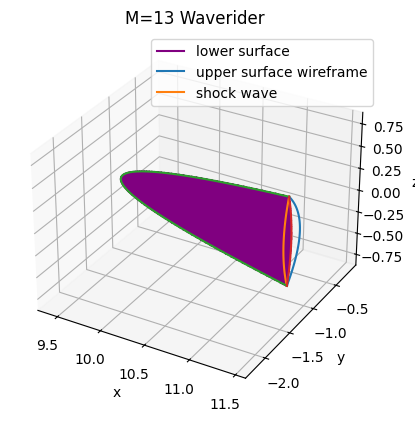

In [14]:
%matplotlib inline
ax = plt.axes(projection="3d")

ax.plot(sx1,sy1,sz1, color='purple', label='lower surface')
ax.plot(p1x, p1y, p1z, label='upper surface wireframe')
ax.plot(p2x, p2y, p2z, label='shock wave')
ax.plot(p3x, p3y, p3z)
ax.plot(p4x, p4y, p4z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.axis('equal')
plt.title('M=13 Waverider')
ax.legend()
plt.show()

<h1>GENERATING SECOND WAVERIDER</h1>
slower speed body

In [15]:
#flow field charcteristics for waverider 2

B = 25 * np.pi/180 #shock angle
M1 = 6 #freestream mach number
#check for B validity
mu = np.arcsin(1/M1)
if B<=mu:
    print('WARNING: Shock Angle less than or equal to Mach Angle')

#stagnation atmospheric conditions taken from ISA
p01 = 101325 #Pa from ISA table at 0 elevation
rho01 = 1.225 #kg/m3
T01 = 288.15 #K
#static atmospheric values calculated using isentropic compressible flow relations
Tupper = T01 * (1+M1**2*(1.4-1)/2)**-1
rhoupper = rho01 * (1+M1**2*(1.4-1)/2)**(-1/(1.4-1))
pupper = p01*(1+(1.4-1)/2*M1**2)**(-1.4/(1.4-1))

d = np.arctan((2*(M1**2*np.sin(B)**2-1))/(np.tan(B)*((1.4+1)*M1**2-2*(M1**2*np.sin(B)**2-1)))) #turning angle
print('turning angle =',d * 180/np.pi,'degrees')
print('static pressure before shock =',pupper,'Pa')
print('static density before shock=',rhoupper,'kg/m3')
print('static temperature before shock=',Tupper,'K')

turning angle = 17.13418064044571 degrees
static pressure before shock = 64.17533273499049 Pa
static density before shock= 0.00636211416060182 kg/m3
static temperature before shock= 35.140243902439025 K


In [16]:
M1n = M1*np.sin(B)
M2n = np.sqrt((1+((1.4-1)/2)*M1n**2)/(1.4*M1n**2-(1.4-1)/2))
M2 = M2n/np.sin(B-d)
print(M2)

3.7238647225217334


In [17]:
vi = (2/((1.4-1)*M2**2) +1)**(-0.5) #non dimensionalised version of V right after the shock, depicted as V' in Anderson
vri = vi*np.cos(B-d)
vti = vi*np.sin(B-d)
print(vri, vti)
print(np.tan(vti/vri)*180/np.pi)

0.8492489791827077 0.11732668969938256
7.966358095822851


In [18]:
#Taylor-Maccoll Solution to find cone body surface for waverider 2

vr = vri
vt = -vti
dt = 0.0000001
n = 0
v_rad = []
v_theta = []
theta = []
while vt<0:
    R = (vr*vt**2-((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)*(2.0*vr+vt/np.tan(B-dt*n)))/(((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)-vt**2.0)
    vr = vr-dt*vt
    vt = vt-dt*R
    n=n+1
    v_rad.append(vr)
    v_theta.append(vt)
    theta.append(B-dt*n)
print(n)
#print((B-dt*n)*180/np.pi,',', vt,',',n)
Bans2 = (-v_theta[n-1])*((theta[n-1]-theta[n-2])/v_theta[n-1]-v_theta[n-2])+theta[n-1] #cone angle
print(Bans2*180/np.pi)

717230
20.89058053556076


In [19]:
#generating waverider body 2

rc = 1 #cone radius in m
amax = 45       *np.pi/180 #max angle of osculating plane
L=round(rc/np.tan(Bans2), 14) #length of cone
p = 101 #number of osculating planes

#osculating planes
a=np.linspace(-np.pi+amax, -np.pi-amax, p)

#base plane
rs = L*np.tan(B) #radius of shock in back plane

p2 = [] #arc of shock cone in back plane
for i in range(len(a)):
    p2.append((L, rs*np.cos(a[i]), rs*np.sin(a[i])))

p1 = [] #design of upper surface
scale= 1
yint = scale*rs**2*(np.sin(amax))**2-rs*np.cos(amax)
p1lims=[-rs*np.sin(amax), rs*np.sin(amax)]

z=np.linspace(p1lims[0], p1lims[1], p)
for i in range(p):
    # if a[i]<-np.pi/2:
    #     z = (np.tan(a[i])+np.sqrt(np.tan(a[i])**2-4*scale*yint))/(-2*scale)
    # else:
    #     z = (np.tan(a[i])-np.sqrt(np.tan(a[i])**2-4*scale*yint))/(-2*scale)
    p1.append((L, (yint-scale*z[i]**2), z[i]))
    # p1.append((L, (yint-scale*z**2), z))
    

p3 = [] #leading edge found by projecting upper surface onto shock cone
for i in range(len(a)):
    p3.append(((p1[i][0]-(-rs*np.cos(amax)-p1[i][1])/np.tan(-B)), p1[i][1], p1[i][2]))
    #p3.append((np.sqrt(1**2*p1[i][1]**2+1**2*p1[i][2]**2), p1[i][1], p1[i][2]))
    #p3.append(((p1[i][0]-(-rs*np.cos(a[i])-p1[i][1])/np.tan(-B)), p1[i][1], p1[i][2]))
p4 = [] #lower surface points found by straight line approximation onto back plane
for i in range(len(a)):
    p4.append((p1[i][0], p1[i][1]-(p1[i][0]-p3[i][0])*np.tan(Bans2), p1[i][2]))



In [20]:
#separating out points in x,y,z
p1x=[]
for i in range(len(a)):
    p1x.append(p1[i][0])

p1y=[]
for i in range(len(a)):
    p1y.append(p1[i][1])
    
p1z=[]
for i in range(len(a)):
    p1z.append(p1[i][2])
    

    
p2x=[]
for i in range(len(a)):
    p2x.append(p2[i][0])

p2y=[]
for i in range(len(a)):
    p2y.append(p2[i][1])
    
p2z=[]
for i in range(len(a)):
    p2z.append(p2[i][2])
    
    

p3x=[]
for i in range(len(a)):
    p3x.append(p3[i][0])

p3y=[]
for i in range(len(a)):
    p3y.append(p3[i][1])
    
p3z=[]
for i in range(len(a)):
    p3z.append(p3[i][2])
    


p4x=[]
for i in range(len(a)):
    p4x.append(p4[i][0])

p4y=[]
for i in range(len(a)):
    p4y.append(p4[i][1])
    
p4z=[]
for i in range(len(a)):
    p4z.append(p4[i][2])

In [21]:
#straight line surface plotting
sx2 = []
sy2 = []
sz2 = []
vtlower = []
vrlower = []
dx = 0.01
inplane = []
for i in range(p):
    xn = p3x[i]
    yn = p3y[i]
    zn = p3z[i]
    vt = -vti
    vr = vri
    n = 0
    while xn <= L:
        sx2.append(xn)
        sy2.append(yn)
        sz2.append(zn)
        vtlower.append(vt)
        vrlower.append(vr)
        rn = np.sqrt(xn**2+yn**2+zn**2)
        tn = np.arccos(xn/rn)
        R  = (vr*vt**2-((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)*(2.0*vr+vt/np.tan(Bans2)))/(((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)-vt**2.0)
        vr = vr-dt*vt
        vt = vt-dt*R 
        xn = xn + dx
        yn = yn - dx*np.tan(Bans2)
        n  = n + 1
    inplane.append(n)

inplane = np.cumsum(inplane)
#print(inplane)

#streamline plotting
sx2 = []
sy2 = []
sz2 = []
vtlower = []
vrlower = []
inplane = []
for i in range(p):
    rn = (p3x[i]**2 + p3y[i]**2 + p3z[i]**2)**0.5
    tn = np.arccos(p3x[i]/(p3x[i]**2+p3y[i]**2+p3z[i]**2)**0.5)
    vt = -vti
    vr = vri
    dr = 0.001
    n = 0
    while rn*np.cos(tn)<=L:        
        sx2.append(rn*np.cos(tn))
        sy2.append(rn*np.sin(tn)*np.cos(a[i]))
        sz2.append(rn*np.sin(tn)*np.sin(a[i]))
        vtlower.append(vt)
        vrlower.append(vr)
        R  = (vr*vt**2-((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)*(2.0*vr+vt/np.tan(tn)))/(((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)-vt**2.0)
        dt = (vt*dr)/(rn*vr)
        vr = vr + dt*vt
        vt = vt + dt*R
        tn = tn + dt
        rn = rn + dr
        n = n + 1
    inplane.append(n)
    



#print(i)
#print(len(sx)+len(sy)+len(sz))
#print(np.tan(vtlower[i]/vrlower[i])*180/np.pi,' ',np.tan(vtlower[0]/vrlower[0])*180/np.pi)

i = 5
rn = (1**2 + (-1)**2 + (-1)**2)**0.5
tn = np.arccos(1/rn)
x = rn*np.cos(tn)
y = rn*np.sin(tn)*np.cos(a[i])
z = rn*np.sin(tn)*np.sin(a[i])
print(p3x[i], p3y[i], p3z[i])
print(x,y,z)

In [22]:
#calculating pressure for each point on surface

Mlower = []
plower = []
p02 = p01*(((1.4+1)/2*M1**2)/(1+(1.4-1)/2*M1**2))**(1.4/(1.4-1))*(1/(2*1.4/(1.4+1)*M1**2-(1.4-1)/(1.4+1)))**(1/(1.4-1))
for i in range(len(vtlower)):
    Mlower.append((2/(0.4*((vtlower[i]**2+vrlower[i]**2)**-1 -1)))**0.5)
    plower.append((1.0+(2.0*1.4*(Mlower[i]**2.0-1.0))/(1.4+1.0))*pupper)

#calculating spanwise lift distribution
lift2d = []
dz2 = (p1z[p-1] - p1z[0])/p
dy = (p1y[p-1] - p1y[0])/(np.ceil(p/2))
n = inplane[0] - 1
i = 0
liftline = []
while i <= (p-1):
    lifttemp = []    
    while n <= (inplane[i]-1):
        lifttemp.append(-(plower[n] - pupper)*(L-p3x[i])*np.cos(a[i]))
        n = n + 1
    n = inplane[i]
    liftline.append(lifttemp)
    i = i + 1

for i in range(p):
    lift2d.append(np.trapezoid(liftline[i], x=None , dx=dx))

lift = np.trapezoid(lift2d, x=None, dx=dz2)

cl2 = lift/(0.5*rhoupper*M1**2*1.4*287*Tupper)

#calculating drag number from base drag which gives pressure drag
cpbase = (2/(1.4*M1**2))*((2/(1.4+1))**1.4*(1/M1)**2.8*((2*1.4*M1**2-(1.4-1))/(1.4+1))-1)
pbase = pupper + 0.5*rhoupper*M1**2*1.4*287*Tupper*cpbase
drag2d = []
dragline = []
n = inplane[0] - 1
i = 0
while i <= (p-1):
    dragtemp = []    
    while n <= (inplane[i]-1):
        dragtemp.append((p1y[i]-p4y[i])*(plower[n]-pbase))
        n = n + 1
    n = inplane[i]
    dragline.append(dragtemp)
    i = i + 1

for i in range(p):
    drag2d.append(np.trapezoid(dragline[i], x=None , dx=dx))

drag = np.trapezoid(drag2d, x=None, dx=dz2)
cd2 = drag/(0.5*rhoupper*M1**2*1.4*287*Tupper)
print(cl2)
print(lift/drag)

1.3268261607087368
2.3820521585455894


<h3>Plotting in each plane</h3>

Text(0, 0.5, 'Lift (N)')

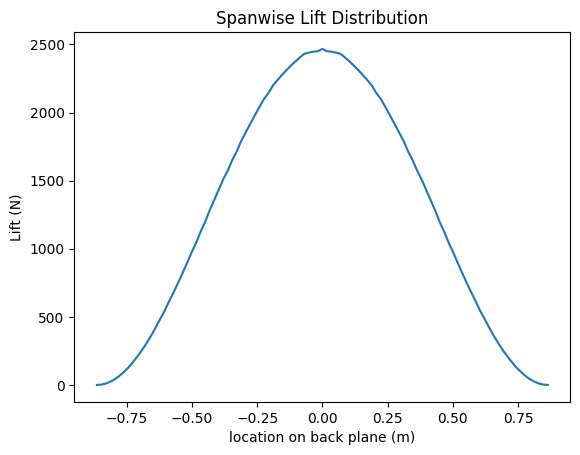

In [23]:
%matplotlib inline
plt.plot(p1z, lift2d)
plt.title('Spanwise Lift Distribution')
plt.xlabel('location on back plane (m)')
plt.ylabel('Lift (N)')

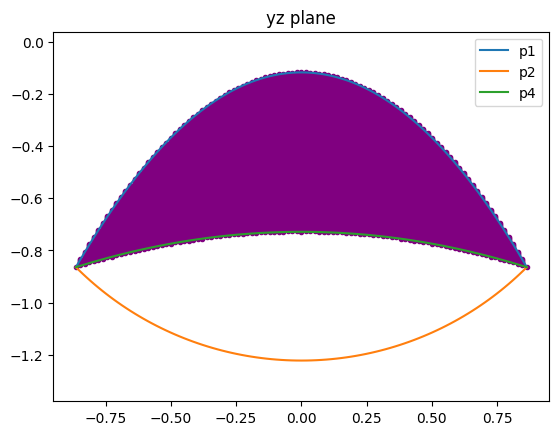

In [24]:
%matplotlib inline
plt.plot(p1z,p1y, label='p1')
plt.plot(p2z,p2y, label='p2')
#plt.plot(p3z,p3y, label='p3')
plt.plot(p4z,p4y, label='p4')
plt.scatter(sz2, sy2, marker='.', color='purple')
plt.title('yz plane')
plt.axis('equal')
plt.legend()

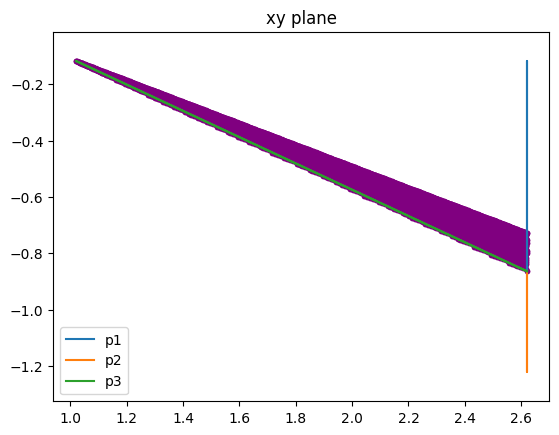

In [25]:
%matplotlib inline
plt.plot(p1x,p1y, label='p1')
plt.plot(p2x,p2y, label='p2')
plt.plot(p3x,p3y, label='p3')
plt.scatter(sx2, sy2, marker=".", color='purple')
#plt.plot(p4x,p4y, label='p4')
# x=np.linspace(0,L,p)
# y=-np.tan(B)*x
# plt.plot(x,y, label='shock')
plt.title('xy plane')
plt.axis('equal')
plt.legend()

(np.float64(0.9395063175065752),
 np.float64(2.7000586278892023),
 np.float64(-0.950292022172808),
 np.float64(0.950292022172808))

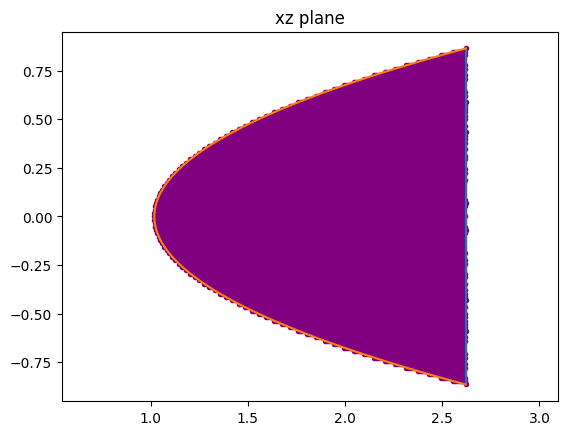

In [26]:
%matplotlib inline
plt.title('xz plane')
plt.plot(p1x,p3z)
plt.plot(p3x,p3z)
plt.scatter(sx2, sz2, color='purple', marker='.')
plt.axis('equal')

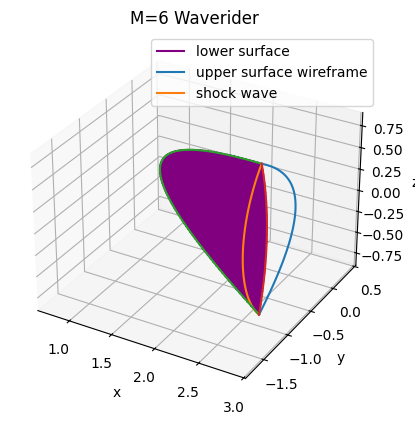

In [27]:
#%matplotlib qt
ax = plt.axes(projection="3d")

ax.plot(sx2,sy2,sz2, color='purple', label='lower surface')
ax.plot(p1x, p1y, p1z, label='upper surface wireframe')
ax.plot(p2x, p2y, p2z, label='shock wave')
ax.plot(p3x, p3y, p3z)
ax.plot(p4x, p4y, p4z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.axis('equal')
plt.title('M=6 Waverider')
ax.legend()
plt.show()

<h1>GENERATING COMBINED WAVERIDER</h1>
can no longer use taylor-maccoll to get aerodynamic data

In [28]:
#finding limits of z for faster waverider, s1
zfl = min(sz1)+(max(sz1)-min(sz1))*0.10
zfu = min(sz1)+(max(sz1)-min(sz1))*(1-0.10)
# xfu = max(sx1)
# xfl = min(sx1)


s1=[]
for i in range(0, len(sx1)):
    s1.append((sx1[i],sy1[i],sz1[i]))


s1cut = []
for i in range(0, len(s1)): #cutting off ends of s1
    if s1[i][2]>zfl and s1[i][2]<zfu:
        s1cut.append(s1[i])


#rotating s1 to match s2
s1rot = []
rot = (Bans2-Bans1)

for i in range(0, len(s1cut)):
    s1rot.append((s1cut[i][0]*np.cos(rot)+s1cut[i][1]*np.sin(rot), -s1cut[i][0]*np.sin(rot)+s1cut[i][1]*np.cos(rot), s1cut[i][2]))
sx1rot = []
for i in range(0, len(s1rot)):
    sx1rot.append(s1rot[i][0])
sy1rot = []
for i in range(0, len(s1rot)):
    sy1rot.append(s1rot[i][1])


#augment s1 to fit design
sx1aug = []
sy1aug = []
for i in range(0, len(s1rot)):
    # sx1aug.append(s1rot[i][0])
    sx1aug.append(s1rot[i][0] - (max(sx1rot)-max(p1x)))
    sy1aug.append(s1rot[i][1] + (max(p3y)-max(sy1rot)) + 0.15) #use of arbitrary adjuster to flush back planes
    # sy1aug.append(s1rot[i][1])


#combine each body's lower surface into tuples

s2=[]
for i in range(0, len(sx2)):
    s2.append((sx2[i],sy2[i],sz2[i]))


#create the combined lower surface

s2cut = []
for i in range(0, len(s2)): #cutting out middle of s2
    if s2[i][2]<zfl:
        s2cut.append(s2[i])
      
    if s2[i][2]>zfu:
        s2cut.append(s2[i])


s3 = []
for i in range(0, len(s2cut)):
    s3.append(s2cut[i])

for i in range(0, len(sx1aug)):
    s3.append((sx1aug[i], sy1aug[i], s1rot[i][2]))

#separating out into x,y,z for combined surface
sx3=[]
sy3=[]
sz3=[]
for i in range(0, len(s3)):
    sx3.append(s3[i][0])
    sy3.append(s3[i][1])
    sz3.append(s3[i][2])

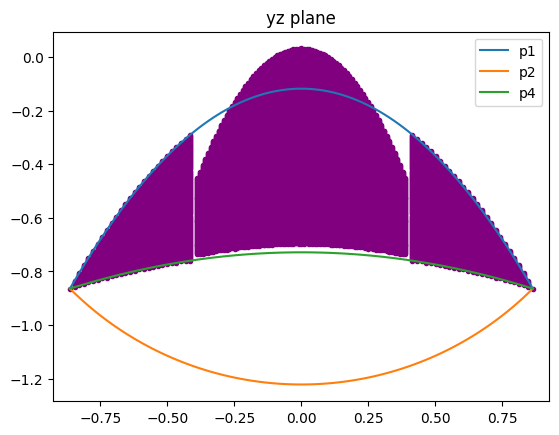

In [29]:
%matplotlib inline
plt.plot(p1z,p1y, label='p1')
plt.plot(p2z,p2y, label='p2')
#plt.plot(p3z,p3y, label='p3')
plt.plot(p4z,p4y, label='p4')
# plt.scatter(sz1,sy1aug, marker='.', color='red')
# plt.scatter(sz2,sy2, marker='.', color='green')
plt.scatter(sz3,sy3, marker='.', color='purple')
plt.title('yz plane')
plt.axis('equal')
plt.legend()

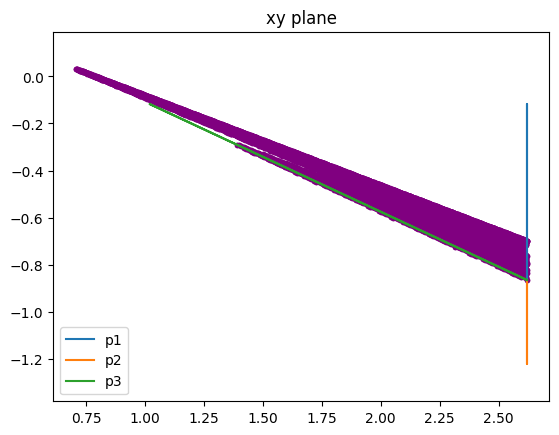

In [30]:
%matplotlib inline
plt.plot(p1x,p1y, label='p1')
plt.plot(p2x,p2y, label='p2')
plt.plot(p3x,p3y, label='p3')
# plt.scatter(sx1aug,sy1aug, marker='.', color='red')
# plt.scatter(sx2,sy2, marker='.', color='green')
plt.scatter(sx3, sy3, marker=".", color='purple')
#plt.plot(p4x,p4y, label='p4')
# x=np.linspace(0,L,p)
# y=-np.tan(B)*x
# plt.plot(x,y, label='shock')
plt.title('xy plane')
plt.axis('equal')
plt.legend()

(np.float64(0.6104408079107388),
 np.float64(2.7157284140604325),
 np.float64(-0.950292022172808),
 np.float64(0.950292022172808))

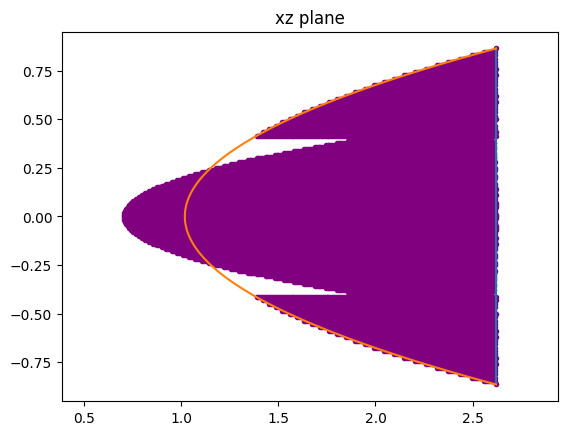

In [31]:
%matplotlib inline
plt.title('xz plane')
plt.plot(p1x,p3z)
plt.plot(p3x,p3z)
# plt.scatter(sx1aug,sz1, marker='.', color='red')
# plt.scatter(sx2,sz2, marker='.', color='green')
plt.scatter(sx3, sz3, color='purple', marker='.')
plt.axis('equal')

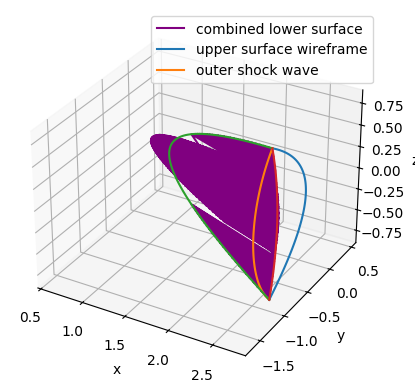

In [40]:
#%matplotlib qt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot(sx3,sy3,sz3, color='purple', label='combined lower surface')
ax.plot(p1x, p1y, p1z, label='upper surface wireframe')
ax.plot(p2x, p2y, p2z, label='outer shock wave')
ax.plot(p3x, p3y, p3z)
ax.plot(p4x, p4y, p4z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.axis('equal')
plt.legend()
plt.show()

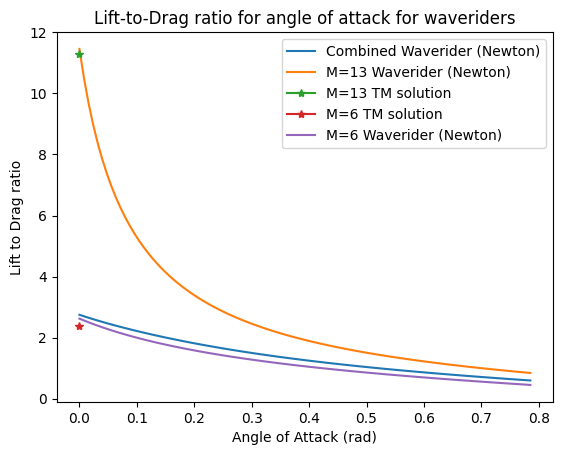

In [39]:
#calculating pressure based on newtonian impact theory

cp = 2*(np.sin(Bans1))**2*(len(sx1aug)*dx*dz1)/(len(s3)*dx*dz1) + 2*(np.sin(Bans2))**2*(len(s2cut)*dx*dz2)/(len(s3)*dx*dz1)

aoa = np.linspace(0, np.pi/4, 100) #radians
ldrc = []
cl = []
cd = []
ldr1 = []
ldr2 = []
for i in range(len(aoa)):
    cl.append(2*(np.sin(Bans1+aoa[i]))**2*np.cos(Bans1+aoa[i])+2*(np.sin(Bans2+aoa[i]))**2*np.cos(Bans2+aoa[i]))
    cd.append(2*(np.sin(Bans1+aoa[i]))**3+2*(np.sin(Bans2+aoa[i]))**3)
    ldrc.append(cl[i]/cd[i])
    ldr1.append((1/np.tan(Bans1+aoa[i])))
    ldr2.append((1/np.tan(Bans2+aoa[i])))
%matplotlib inline
plt.plot(aoa, ldrc, label='Combined Waverider (Newton)')
plt.plot(aoa, ldr1, label='M=13 Waverider (Newton)')
plt.plot(0, 11.279802371525541, marker='*', label='M=13 TM solution')
plt.plot(0, 2.38203699128867, marker='*', label='M=6 TM solution')
plt.plot(aoa, ldr2, label='M=6 Waverider (Newton)')
plt.title('Lift-to-Drag ratio for angle of attack for waveriders')
# plt.axis('equal')
plt.legend()
plt.xlabel('Angle of Attack (rad)')
plt.ylabel('Lift to Drag ratio')
plt.show()

<h1>Plotting Taylor Maccoll Solution for a range of Mach numbers</h1>

In [34]:
def tm(m, b):
    
    #flow field charcteristics for waverider 2

    B = b * np.pi/180 #shock angle
    M1 = m #freestream mach number
    #check for B validity
    mu = np.arcsin(1/M1)
    if B<=mu:
        print('WARNING: Shock Angle less than or equal to Mach Angle')
    
    #stagnation atmospheric conditions taken from ISA
    p01 = 101325 #Pa from ISA table at 0 elevation
    rho01 = 1.225 #kg/m3
    T01 = 288.15 #K
    #static atmospheric values calculated using isentropic compressible flow relations
    Tupper = T01 * (1+M1**2*(1.4-1)/2)**-1
    rhoupper = rho01 * (1+M1**2*(1.4-1)/2)**(-1/(1.4-1))
    pupper = p01*(1+(1.4-1)/2*M1**2)**(-1.4/(1.4-1))
    
    d = np.arctan((2*(M1**2*np.sin(B)**2-1))/(np.tan(B)*((1.4+1)*M1**2-2*(M1**2*np.sin(B)**2-1)))) #turning angle
    # print('turning angle =',d * 180/np.pi,'degrees')
    # print('static pressure before shock =',pupper,'Pa')
    # print('static density before shock=',rhoupper,'kg/m3')
    # print('static temperature before shock=',Tupper,'K')
    
    M1n = M1*np.sin(B)
    M2n = np.sqrt((1+((1.4-1)/2)*M1n**2)/(1.4*M1n**2-(1.4-1)/2))
    M2 = M2n/np.sin(B-d)
    # print(M2)
    
    vi = (2/((1.4-1)*M2**2) +1)**(-0.5) #non dimensionalised version of V right after the shock, depicted as V' in Anderson
    vri = vi*np.cos(B-d)
    vti = vi*np.sin(B-d)
    # print(vri, vti)
    # print(np.tan(vti/vri)*180/np.pi)
    
    #Taylor-Maccoll Solution to find cone body surface for waverider 2
    
    vr = vri
    vt = -vti
    dt = 0.0000001
    n = 0
    v_rad = []
    v_theta = []
    theta = []
    while vt<0:
        R = (vr*vt**2-((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)*(2.0*vr+vt/np.tan(B-dt*n)))/(((1.4-1.0)/2.0)*(1.0-vr**2.0-vt**2.0)-vt**2.0)
        vr = vr-dt*vt
        vt = vt-dt*R
        n=n+1
        v_rad.append(vr)
        v_theta.append(vt)
        theta.append(B-dt*n)
    # print(n)
    #print((B-dt*n)*180/np.pi,',', vt,',',n)
    Bans2 = (-v_theta[n-1])*((theta[n-1]-theta[n-2])/v_theta[n-1]-v_theta[n-2])+theta[n-1] #cone angle
    Bans2deg = Bans2*180/np.pi

    return Bans2deg

In [35]:
M1 = np.linspace(5, 15, 11)
cone25 = []
cone20 = []
cone15 = []
cone10 = []

for i in range(len(M1)):
    cone25.append(tm(M1[i], 25))
    cone20.append(tm(M1[i], 20))
    cone15.append(tm(M1[i], 15))
    

# print(Cone)

<function matplotlib.pyplot.show(close=None, block=None)>

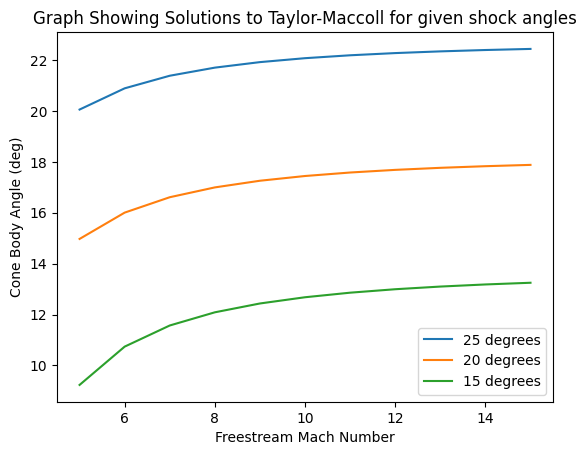

In [36]:
%matplotlib inline

plt.plot(M1, cone25, label='25 degrees')
plt.plot(M1, cone20, label='20 degrees')
plt.plot(M1, cone15, label='15 degrees')
plt.legend()
plt.title('Graph Showing Solutions to Taylor-Maccoll for given shock angles')
plt.xlabel('Freestream Mach Number')
plt.ylabel('Cone Body Angle (deg)')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

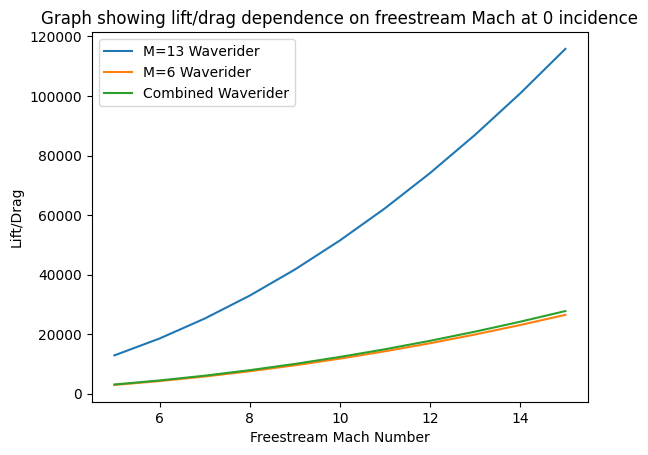

In [37]:
l1 = []
l2 = []
lc = []
cl1 = (2*(np.sin(Bans1))**2*np.cos(Bans1))
cl2 = (2*(np.sin(Bans2))**2*np.cos(Bans2))
clc = 2*(np.sin(Bans1))**2*np.cos(Bans1)+2*(np.sin(Bans2))**2*np.cos(Bans2)
# for i in range(len(M1)):
#     l1.append(cl1*0.5*rhoupper*M1[i]**2*1.4*287*Tupper)
#     l2.append(cl2*0.5*rhoupper*M1[i]**2*1.4*287*Tupper)
#     lc.append(clc*0.5*rhoupper*M1[i]**2*1.4*287*Tupper)

for i in range(len(M1)):
    l1.append(ldr1[0]*0.5*rhoupper*M1[i]**2*1.4*287*Tupper)
    l2.append(ldr2[0]*0.5*rhoupper*M1[i]**2*1.4*287*Tupper)
    lc.append(ldrc[0]*0.5*rhoupper*M1[i]**2*1.4*287*Tupper)

%matplotlib inline

plt.plot(M1, l1, label='M=13 Waverider')
plt.plot(M1, l2, label='M=6 Waverider')
plt.plot(M1, lc, label='Combined Waverider')
# plt.plot(13, 11.279796113302554, marker='*', label='M=13')
# plt.plot(6, 2.3820521585455894, marker='*', label='M=6')
# plt.plot(9, ldrc[0], marker='*', label='combined')
plt.legend()
plt.title('Graph showing lift/drag dependence on freestream Mach at 0 incidence')
plt.xlabel('Freestream Mach Number')
plt.ylabel('Lift/Drag')
plt.show